- 知识点
- 张量类型和定义
- 索引、切片、变换
- 张量的内部结构
- 自动微分 Autograd
- 深度学习框架对比
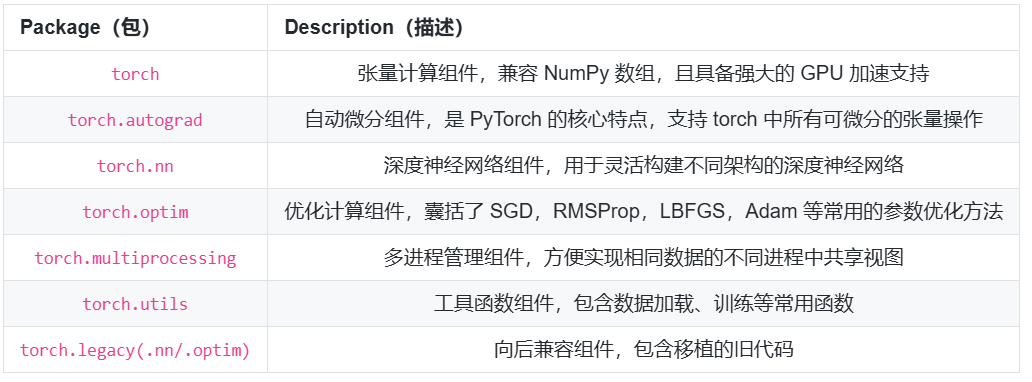
## 张量的类型 ##
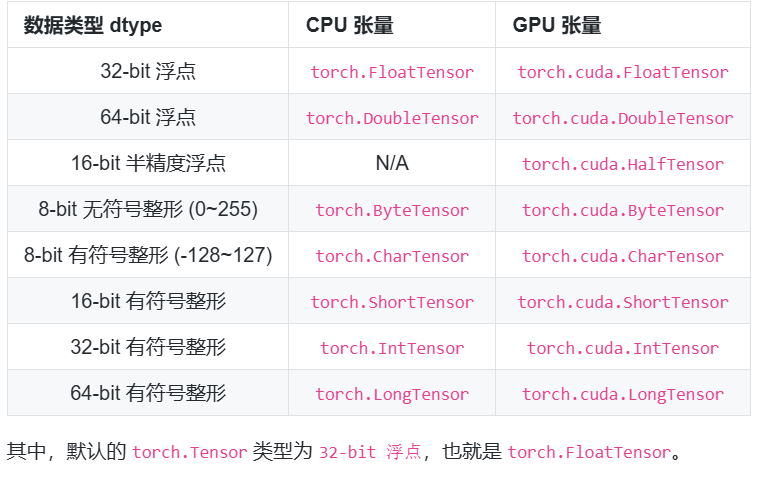

In [1]:
import torch as t

t.Tensor().dtype

torch.float32

In [2]:
# 如果你想指定全局为某种类型的 Tensor，使得代码书写起来更加方便，就可以通过配置完成，例如：
t.set_default_tensor_type('torch.DoubleTensor')
t.Tensor().dtype

d:\App\Anaconda\Lib\site-packages\torch\__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\tensor\python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


torch.float64

In [3]:
# 当然，最常用的就是默认的 torch.Tensor() ，也就是 torch.FloatTensor()。我们还原配置：
t.set_default_tensor_type('torch.FloatTensor')
t.Tensor().dtype

torch.float32

In [4]:
# 说完 PyTorch 中支持 Tensor 的类型，接下来我们看一看如何创建 Tensor。当然，最基础的方式是传入一个列表，即可创建：
t.Tensor([1, 2, 3])

tensor([1., 2., 3.])

In [5]:
# 还记得上面提到过 PyTorch 张量兼容 NumPy 数组吗？我们也可以直接通过 NumPy 数组来创建张量。
import numpy as np

t.Tensor(np.random.randn(3))

tensor([-1.0639,  1.3990, -0.4412])

In [6]:
t.Tensor([[1, 2], [3, 4], [5, 6]]).shape

torch.Size([3, 2])

## 张量的定义 ##
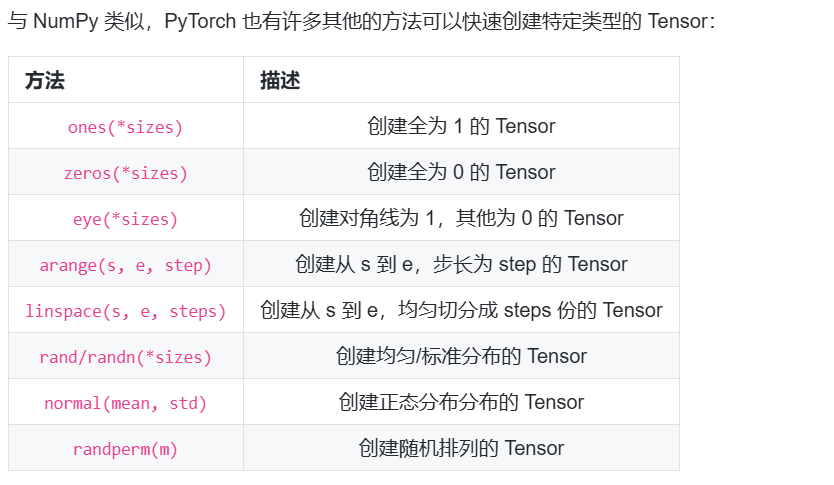

## 张量的数学运算 ##

In [7]:
# 学会 Tensor 的花式创建方法之后，我们再了解一下 Tensor 的基本运算。首先，两个 Tensor 是可以直接相互加减的，但要保证形状一致：
a = t.Tensor([[1, 2], [3, 4]])
b = t.Tensor([[5, 6], [7, 8]])

print(a + b)
print(a - b)

tensor([[ 6.,  8.],
        [10., 12.]])
tensor([[-4., -4.],
        [-4., -4.]])


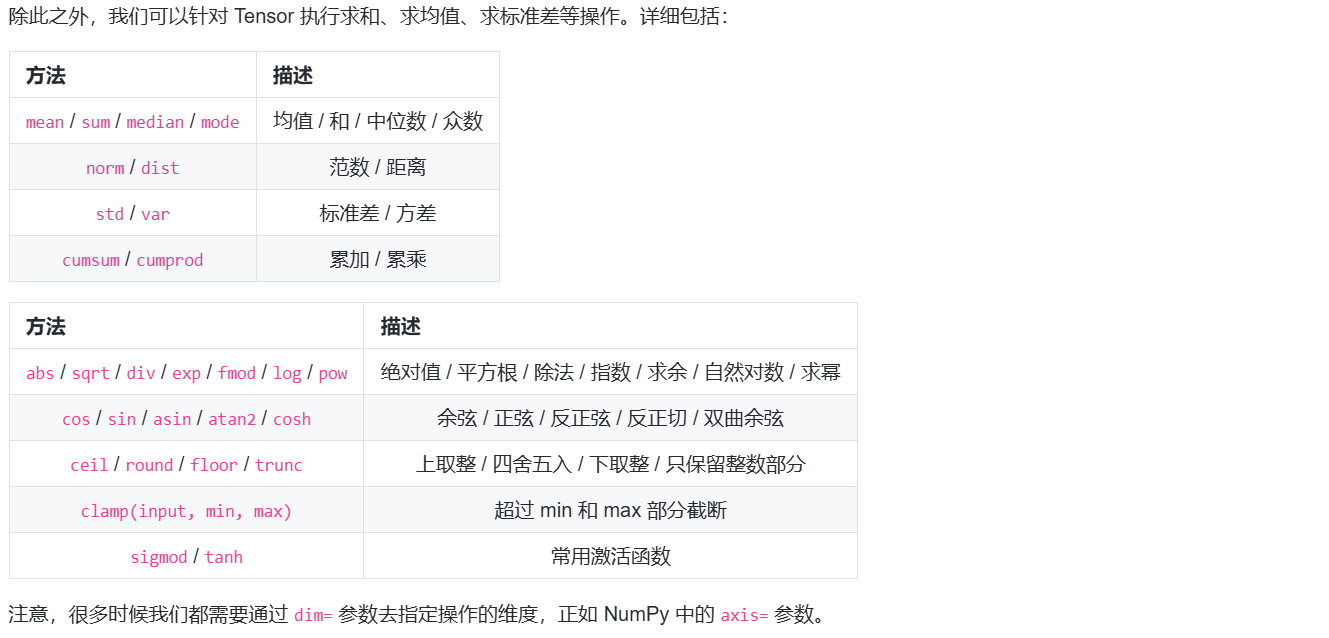

In [8]:
# 对 a 求列平均
a.mean(dim=0)

tensor([2., 3.])

In [9]:
# a 中的每个元素求平方
a.pow(2)

tensor([[ 1.,  4.],
        [ 9., 16.]])

In [10]:
# a 中的每个元素传入 sigmoid 函数
a.sigmoid()

tensor([[0.7311, 0.8808],
        [0.9526, 0.9820]])

## 张量的线性代数运算 ##
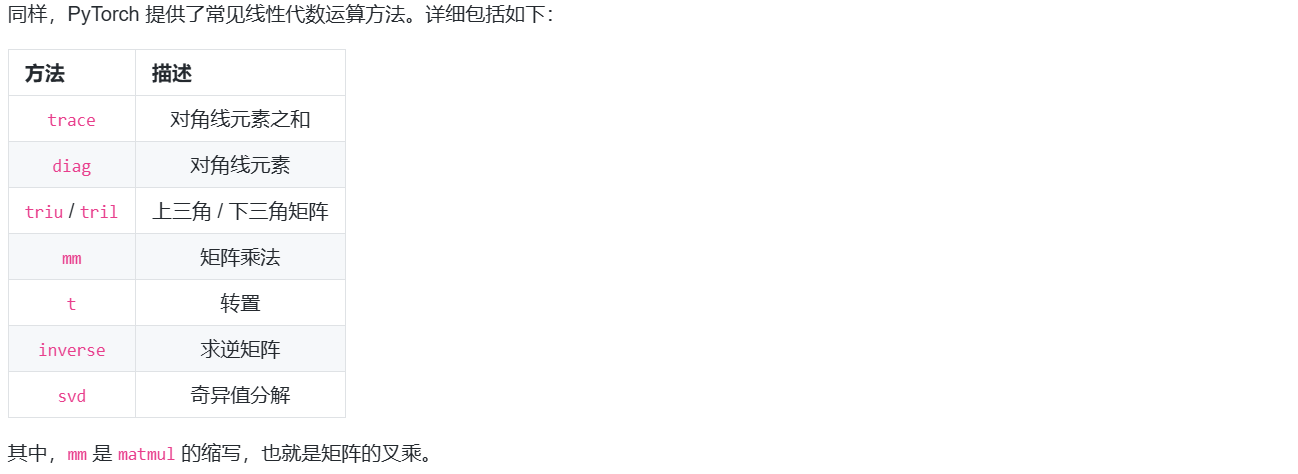

In [11]:
b.mm(a), b.matmul(a)

(tensor([[23., 34.],
         [31., 46.]]),
 tensor([[23., 34.],
         [31., 46.]]))

## 索引，切片，变换 ##

In [12]:
c = t.rand(5, 4)
c

tensor([[0.2389, 0.0310, 0.8930, 0.9318],
        [0.3947, 0.8072, 0.1998, 0.5051],
        [0.9082, 0.9606, 0.7197, 0.5946],
        [0.1747, 0.1177, 0.7652, 0.0809],
        [0.0446, 0.5436, 0.2430, 0.4477]])

In [13]:
# 取第 1 行
c[0]

tensor([0.2389, 0.0310, 0.8930, 0.9318])

In [14]:
# 取第 1 列
c[:, 0]

tensor([0.2389, 0.3947, 0.9082, 0.1747, 0.0446])

In [15]:
# 取第 2, 3 行与 3, 4 列
c[1:3, 2:4]

tensor([[0.1998, 0.5051],
        [0.7197, 0.5946]])

In [16]:
c.reshape(4, 5)

tensor([[0.2389, 0.0310, 0.8930, 0.9318, 0.3947],
        [0.8072, 0.1998, 0.5051, 0.9082, 0.9606],
        [0.7197, 0.5946, 0.1747, 0.1177, 0.7652],
        [0.0809, 0.0446, 0.5436, 0.2430, 0.4477]])

In [17]:
c.view(4, 5)

tensor([[0.2389, 0.0310, 0.8930, 0.9318, 0.3947],
        [0.8072, 0.1998, 0.5051, 0.9082, 0.9606],
        [0.7197, 0.5946, 0.1747, 0.1177, 0.7652],
        [0.0809, 0.0446, 0.5436, 0.2430, 0.4477]])

对应reshape()，resize() 和 view()，三者直接的区别在于：resize() 和 view() 执行变换时和原 Tensor 共享内存，即修改一个，另外一个也会跟着改变。而 reshape() 则会复制到新的内存区块上。

## 张量的内部结构 ##
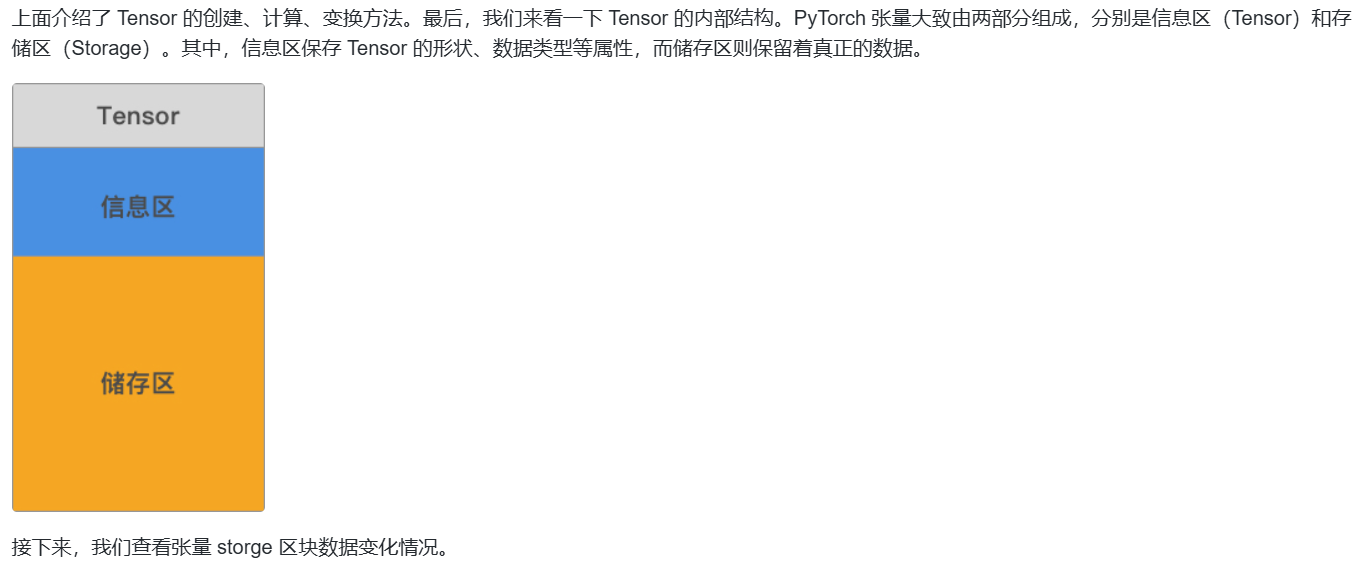

In [18]:
d = t.rand(3, 2)  # 生成一个随机张量
d

tensor([[0.9122, 0.2278],
        [0.0162, 0.6218],
        [0.5300, 0.3674]])

In [19]:
d.storage()  # 查看张量 storge 区块

C:\Users\35096\AppData\Local\Temp\ipykernel_24648\4058410646.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  d.storage()  # 查看张量 storge 区块


 0.9122424721717834
 0.227766215801239
 0.01618325710296631
 0.621760904788971
 0.5299597382545471
 0.36744481325149536
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

In [20]:
d = d.reshape(2, 3)  # 改变张量的形状
d

tensor([[0.9122, 0.2278, 0.0162],
        [0.6218, 0.5300, 0.3674]])

In [21]:
d.storage()  # 查看改变后张量 storge 区块

 0.9122424721717834
 0.227766215801239
 0.01618325710296631
 0.621760904788971
 0.5299597382545471
 0.36744481325149536
[torch.storage.TypedStorage(dtype=torch.float32, device=cpu) of size 6]

可以看到，虽然 Tensor 的 size 属性改变，但是 Storge 则不会改变。当然，我们这里只是一个简单的概括，并不是特别严谨

## 自动微分Autograd ##
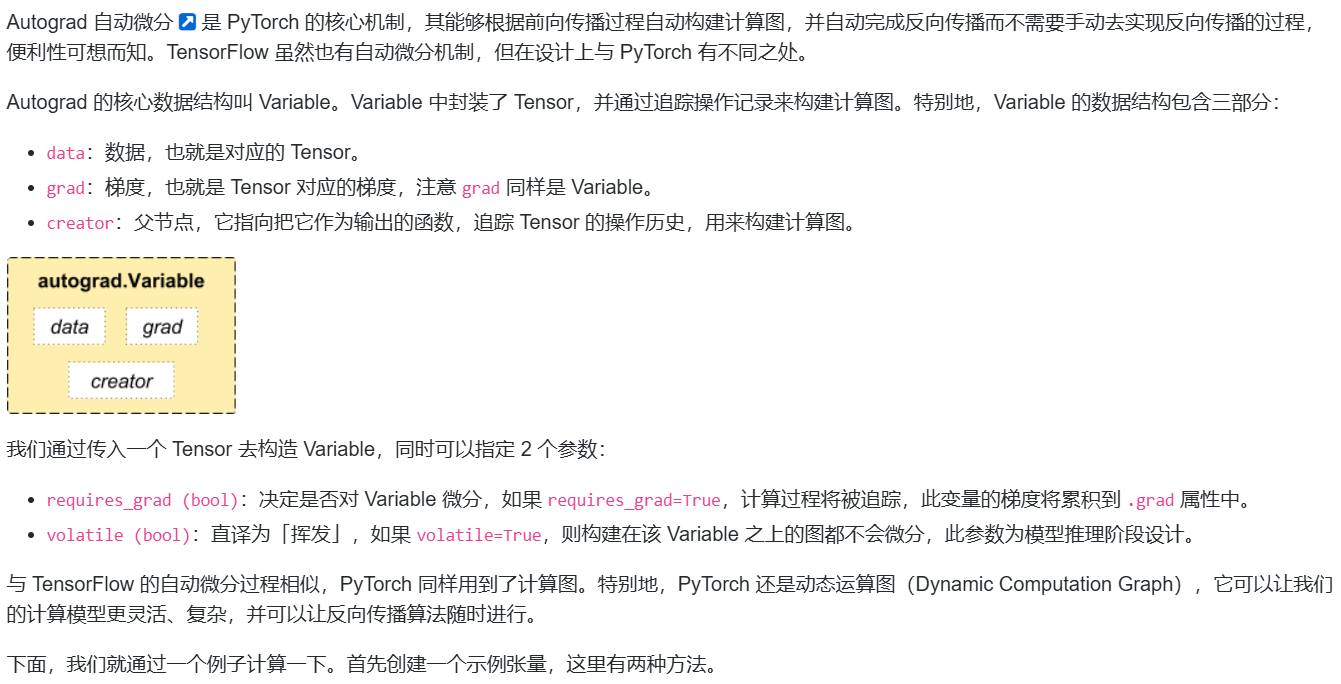

In [22]:
# 方法 1：创建张量并使用 Variable 封装：
from torch.autograd import Variable

x = Variable(t.ones(3, 4), requires_grad=True)
x

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], requires_grad=True)

In [23]:
# 方法 2：使用 PyTorch 提供的方法创建张量时指定 requires_grad=True 即默认使用 Variable 封装，更为简单：
x = t.ones(3, 4, requires_grad=True)
x

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], requires_grad=True)

In [24]:
print(x.data)
print(x.grad)
print(x.grad_fn)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
None
None


In [25]:
# 因为这里没有计算过程，所以 grad 和 grad_fn 都是 None。我们可以对 x 执行一次运算
y = x + 2
print(y)
y.grad_fn

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]], grad_fn=<AddBackward0>)


In [26]:
z = t.mean(y.pow(3))
print(z)
z.grad_fn

tensor(27., grad_fn=<MeanBackward0>)


In [27]:
# 此时，你可以使用 backward 进行反向传播，并计算所有叶子节点的导数（梯度）。注意，Z 和 Y 都不是叶子节点，所以都没有梯度信息
z.backward()
print(z.is_leaf, y.is_leaf, x.is_leaf)
print(z.grad)
print(y.grad)
print(x.grad)

False False True
None
None
tensor([[2.2500, 2.2500, 2.2500, 2.2500],
        [2.2500, 2.2500, 2.2500, 2.2500],
        [2.2500, 2.2500, 2.2500, 2.2500]])


C:\Users\35096\AppData\Local\Temp\ipykernel_24648\445266043.py:4: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print(z.grad)
C:\Users\35096\AppData\Local\Temp\ipykernel_24648\445266043.py:5: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access 

注意，由于梯度是会累计的，所以重复运行计算 Z 的代码就相当于修改了计算图，相应的梯度值也会发生变化。除此之外，如果你重复运行 backward() 会报错，原因是前向传递过程之后将所需数值保存为 buffer，当计算完梯度之后会自动清空。如果想要多次反向传播，那就需要通过 backward(retain_graph=True) 参数来保证 buffer 的持久性。

In [28]:
x = t.randn(3, 4, requires_grad=True)
print(x)

def sigmoid(x):
    """sigmoid 函数"""
    return 1.0/(1.0 + t.exp(-x))

def sigmoid_derivative(x):
    """sigmoid 函数求导"""
    return sigmoid(x)*(1.0-sigmoid(x))

y = sigmoid(x)  # 张量通过 sigmoid 计算
print(y)

print(sigmoid_derivative(x))  # 计算 sigmoid 的导数

y.backward(gradient=t.ones(y.size()))
x.grad

tensor([[-5.6099e-01, -1.0971e+00,  1.5287e+00,  1.2463e-01],
        [ 7.8017e-01, -2.2691e+00, -1.2183e+00, -1.2475e-04],
        [ 7.8101e-01, -5.6354e-01, -3.5045e-01,  5.7939e-01]],
       requires_grad=True)
tensor([[0.3633, 0.2503, 0.8218, 0.5311],
        [0.6857, 0.0937, 0.2282, 0.5000],
        [0.6859, 0.3627, 0.4133, 0.6409]], grad_fn=<MulBackward0>)
tensor([[0.2313, 0.1876, 0.1464, 0.2490],
        [0.2155, 0.0849, 0.1761, 0.2500],
        [0.2154, 0.2312, 0.2425, 0.2301]], grad_fn=<MulBackward0>)


tensor([[0.2313, 0.1876, 0.1464, 0.2490],
        [0.2155, 0.0849, 0.1761, 0.2500],
        [0.2154, 0.2312, 0.2425, 0.2301]])